# 10: Attendance Model, Linear (Accessibility) Stage

**linear stage** of a two-stage residual model completed in `11_catboost_attendance_model.ipynb`:

1. This notebook fits `log_attendance ~ log_metro_size` (accessibility only, univariate),
   clustered SE by team, on the same table CatBoost uses (`catboost_training_table.csv`, built
   by `09`).
2. `11` loads this notebook's fitted coefficient, computes `residual = log_attendance -
   linear_pred`, and trains CatBoost on the residual using every other feature *except*
   `metro_size`.
3. Final prediction = `exp(linear_pred + catboost_residual_pred)`.

CatBoost (a tree model) cannot extrapolate past the range of values
it was trained on, and Gotham's accessibility is unprecedented (more than 2x what the model has seen).
Accessibility gets pulled out into its own linear stage, and CatBoost is left to model everything
else (day of week, opponent rank, stadium capacity, etc. are
all in-range for Etihad Park).

**Inputs:** `data/processed/catboost_training_table.csv` (11's output)
**Outputs:** `output/attendance_linear_model_coefficients.csv` (pipeline input to `11`),
`output/nwsl_attendance_accessibility_coefficient.png`,
`output/nwsl_attendance_linear_predicted_vs_actual.png`,
`output/nwsl_attendance_linear_lovo_results.csv`

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

from plot_theme import set_mpl_theme, COLOR_PRIMARY, COLOR_NEGATIVE, NWSL_PALETTE
set_mpl_theme()

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
df = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "catboost_training_table.csv"), parse_dates=["date_time_utc"])
df["log_metro_size"] = np.log(df["metro_size"])
print(f"Loaded {len(df)} rows, {df['home_team'].nunique()} teams, seasons {sorted(df['year'].unique())}")
print(f"metro_size missing for {df['metro_size'].isna().sum()} / {len(df)} rows "
      f"(old/renamed venues never run through the isochrone build) -- dropped below.")
print(f"log_metro_size chosen over raw metro_size specifically because it compresses the value "
      f"range -- Etihad Park's real catchment (3.2M) is 2.2x the largest value ever observed in "
      f"raw units, but only ~0.78 log-units past the training max in log space, a far smaller, "
      f"more defensible extrapolation for the linear stage to make (see 12).")

Loaded 1132 rows, 14 teams, seasons [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
metro_size missing for 182 / 1132 rows (old/renamed venues never run through the isochrone build) -- dropped below.
log_metro_size chosen over raw metro_size specifically because it compresses the value range -- Etihad Park's real catchment (3.2M) is 2.2x the largest value ever observed in raw units, but only ~0.78 log-units past the training max in log space, a far smaller, more defensible extrapolation for the linear stage to make (see 12).


### Just regress on `log_metro_size` 

In [3]:
reg_df = df.dropna(subset=["log_metro_size", "log_attendance"]).reset_index(drop=True)
print(f"{len(reg_df)} rows with a real metro_size value, {reg_df['home_team'].nunique()} teams")

model = smf.ols("log_attendance ~ log_metro_size", data=reg_df).fit(
    cov_type="cluster", cov_kwds={"groups": reg_df["home_team"]}
)
print(model.summary())

950 rows with a real metro_size value, 14 teams
                            OLS Regression Results                            
Dep. Variable:         log_attendance   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     4.284
Date:                Tue, 25 Aug 2026   Prob (F-statistic):             0.0590
Time:                        13:36:51   Log-Likelihood:                -767.74
No. Observations:                 950   AIC:                             1539.
Df Residuals:                     948   BIC:                             1549.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [4]:
coef_table = pd.DataFrame({
    "predictor": model.params.index,
    "coef": model.params.values,
    "ci_low": model.conf_int()[0].values,
    "ci_high": model.conf_int()[1].values,
    "p_value": model.pvalues.values,
})
coef_table.to_csv(os.path.join(OUTPUT_DIR, "attendance_linear_model_coefficients.csv"), index=False)
print(coef_table.to_string(index=False))

     predictor     coef   ci_low  ci_high      p_value
     Intercept 6.759133 4.743119 8.775148 4.990725e-11
log_metro_size 0.177182 0.009394 0.344970 3.848035e-02


### Coefficient plot (with 95% CI, clustered by team)

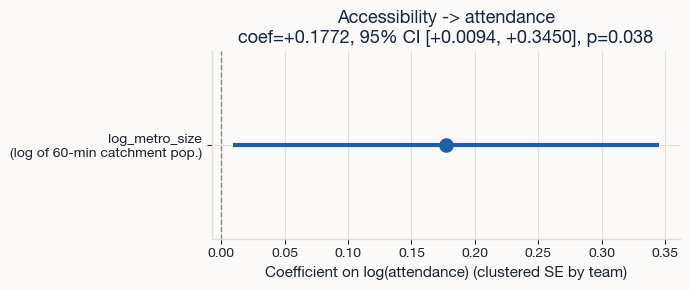

In [5]:
plt.figure(figsize=(7, 3))
row = coef_table[coef_table["predictor"] == "log_metro_size"].iloc[0]
plt.hlines(0, row["ci_low"], row["ci_high"], color=COLOR_PRIMARY, linewidth=3)
plt.scatter([row["coef"]], [0], color=COLOR_PRIMARY, s=90, zorder=3)
plt.axvline(0, linestyle="--", color="#888888", linewidth=1)
plt.yticks([0], ["log_metro_size\n(log of 60-min catchment pop.)"])
plt.xlabel("Coefficient on log(attendance) (clustered SE by team)")
plt.title(f"Accessibility -> attendance\ncoef={row['coef']:+.4f}, 95% CI [{row['ci_low']:+.4f}, {row['ci_high']:+.4f}], p={row['p_value']:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_attendance_accessibility_coefficient.png"), dpi=150)
plt.show()

## Leave-One-Venue-Out (LOVO)

80/20 fit, and a **Leave-One-Venue-Out (LOVO)** cross-validation. Originally used Leave-One-Team-Out, but didn't make sense in the project scope.

In [6]:
def raw_metrics(y_true_log, y_pred_log):
    y_true, y_pred = np.exp(y_true_log), np.exp(y_pred_log)
    return dict(
        r2=r2_score(y_true_log, y_pred_log),
        pearson_r=pearsonr(y_true_log, y_pred_log)[0],
        mae=mean_absolute_error(y_true, y_pred),
        rmse=np.sqrt(mean_squared_error(y_true, y_pred)),
    )

naive_pred = model.predict(reg_df)
naive_metrics = raw_metrics(reg_df["log_attendance"].values, naive_pred.values)
print("Naive (in-sample) fit:", {k: round(v, 3) for k, v in naive_metrics.items()})

Naive (in-sample) fit: {'r2': 0.154, 'pearson_r': np.float64(0.392), 'mae': 4067.62, 'rmse': np.float64(5425.691)}


In [7]:
venue_pairs = reg_df.groupby(["home_team", "venue_name"]).size().reset_index(name="n_games")
print(f"{len(venue_pairs)} (team, venue) pairs, {(venue_pairs['n_games'] >= 10).sum()} with >=10 games")

lovo_true, lovo_pred, lovo_team, lovo_venue = [], [], [], []
lovo_rows = []
for _, pair in venue_pairs.iterrows():
    team, venue = pair["home_team"], pair["venue_name"]
    is_held_out = (reg_df["home_team"] == team) & (reg_df["venue_name"] == venue)
    train, test = reg_df[~is_held_out], reg_df[is_held_out]
    fold_model = smf.ols("log_attendance ~ log_metro_size", data=train).fit()
    y_pred = fold_model.predict(test)
    m = raw_metrics(test["log_attendance"].values, y_pred.values)
    lovo_rows.append({"team": team, "venue_name": venue, "n_games": len(test), **m,
                       "mean_attendance": test["attendance"].mean()})
    lovo_true.extend(test["log_attendance"].tolist())
    lovo_pred.extend(y_pred.tolist())
    lovo_team.extend([team] * len(test))
    lovo_venue.extend([venue] * len(test))

lovo_df = pd.DataFrame(lovo_rows).sort_values("mae")
lovo_df.to_csv(os.path.join(OUTPUT_DIR, "nwsl_attendance_linear_lovo_results.csv"), index=False)
print(lovo_df.to_string(index=False))

pooled_metrics = raw_metrics(np.array(lovo_true), np.array(lovo_pred))
print("\nLOVO pooled:", {k: round(v, 3) for k, v in pooled_metrics.items()})

# Saved so summary_tables.py's Table 3 / the site's model-comparison table can read real computed
# numbers instead of hand-transcribing them from notebook output.
pd.DataFrame([
    {"scheme": "naive (in-sample)", **naive_metrics},
    {"scheme": "Leave-One-Venue-Out (pooled)", **pooled_metrics},
]).to_csv(os.path.join(OUTPUT_DIR, "nwsl_attendance_linear_fit_summary.csv"), index=False)

17 (team, venue) pairs, 16 with >=10 games
                  team            venue_name  n_games         r2  pearson_r         mae         rmse  mean_attendance
      Seattle Reign FC        Cheney Stadium       12  -0.573900        NaN 1560.661299  1976.169900      5212.583333
North Carolina Courage   WakeMed Soccer Park      103  -0.008021        NaN 1716.788642  2080.310608      5868.300971
  Racing Louisville FC   Lynn Family Stadium       62  -1.508611        NaN 2017.471437  2233.988711      5844.048387
     Washington Spirit   Maryland SoccerPlex       44  -4.162686        NaN 2161.896160  2339.264478      3614.931818
        Utah Royals FC   America First Field       59  -0.207125        NaN 2446.769988  3891.255705      9777.338983
         Orlando Pride      Inter&Co Stadium       98  -0.415663        NaN 2896.482109  3655.278868      6797.632653
     San Diego Wave FC        Torero Stadium       11 -16.138371        NaN 3067.739254  3127.609368      5288.636364
      Seattle

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_75195/3035702855.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r=pearsonr(y_true_log, y_pred_log)[0],
/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_75195/3035702855.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r=pearsonr(y_true_log, y_pred_log)[0],
/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_75195/3035702855.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r=pearsonr(y_true_log, y_pred_log)[0],
/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_75195/3035702855.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r=pearsonr(y_true_log, y_pred_log)[0],
/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_75195/3035702855.py:5: ConstantInputWarni

### Predicted vs. actual (naive fit vs. LOVO), colored by team

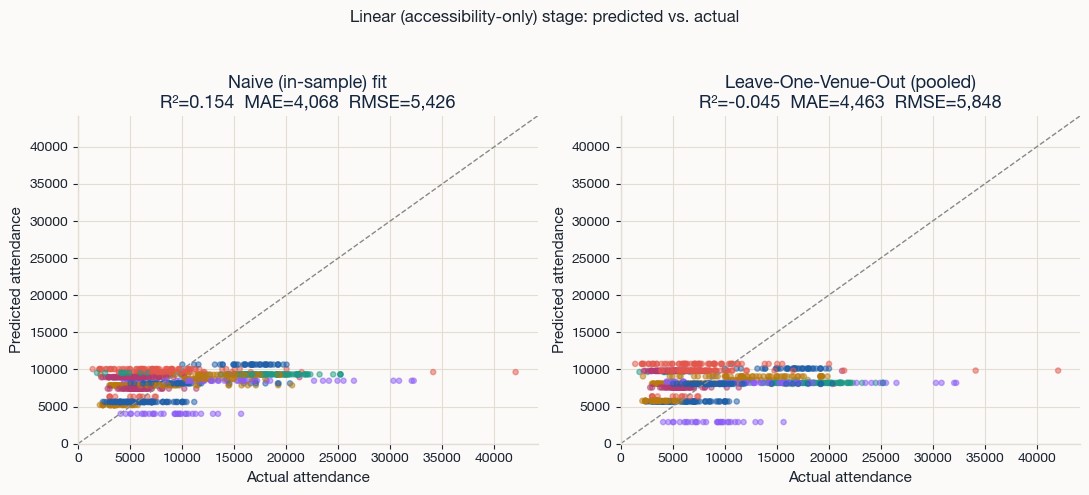

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_specs = [
    (axes[0], reg_df["attendance"].values, np.exp(naive_pred.values), naive_metrics, "Naive (in-sample) fit"),
    (axes[1], np.exp(np.array(lovo_true)), np.exp(np.array(lovo_pred)), pooled_metrics, "Leave-One-Venue-Out (pooled)"),
]
teams = sorted(reg_df["home_team"].unique())
team_color = {t: NWSL_PALETTE[i % len(NWSL_PALETTE)] for i, t in enumerate(teams)}
lovo_team_arr = np.array(lovo_team)

for ax, y_true, y_pred, m, title in plot_specs:
    if title.startswith("Naive"):
        colors = reg_df["home_team"].map(team_color)
    else:
        colors = pd.Series(lovo_team_arr).map(team_color)
    ax.scatter(y_true, y_pred, s=14, alpha=0.5, c=colors)
    lims = [0, max(y_true.max(), y_pred.max()) * 1.05]
    ax.plot(lims, lims, "--", color="#888888", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual attendance"); ax.set_ylabel("Predicted attendance")
    ax.set_title(f"{title}\nR²={m['r2']:.3f}  MAE={m['mae']:,.0f}  RMSE={m['rmse']:,.0f}")

fig.suptitle("Linear (accessibility-only) stage: predicted vs. actual", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(os.path.join(OUTPUT_DIR, "nwsl_attendance_linear_predicted_vs_actual.png"), dpi=150)
plt.show()

**Reading this**: the standalone R² here is low (this model only carries one feature, by
design), but the LOVO and naive fits track each other reasonably, because a single linear
coefficient on a between-team-varying feature doesn't have much room to overfit to venue
identity the way a flexible tree model does. 